# PROC FASTCLUS를 활용한 가입자 행동 K-평균 세그먼트 분석


## 요약

이 노트북은 Base SAS의 k-평균 군집화 프로시저인 `PROC FASTCLUS`를 사용하여 가상의 이동통신 가입자 100명을 행동 기반 클러스터로 분류한다. 7개의 이용 특성은 `PROC STDIZE`로 z-점수로 표준화하여, 값의 크기가 큰 변수(음성 통화 시간, SMS 건수)가 유클리드 거리를 지배하지 않도록 한 뒤, `PROC FASTCLUS`가 3개의 클러스터를 적합한다. 이 프로시저는 클러스터 내 RMS 편차, 세그먼트 분리 정도를 나타내는 전체 R-제곱 및 pseudo-F(여기서는 전체 R-제곱 0.575, pseudo-F 65.75)를 보고하며, 모든 가입자에 `CLUSTER` 라벨이 붙은 채점 테이블을 생성한다. 이 라벨을 원래 스케일의 데이터에 다시 결합하여 페르소나를 프로파일링하고, 그 결과를 후속 활성화 단계로 넘긴다.

## 데이터 소스

| 데이터셋 | 설명 | 행 수 | 주요 변수 |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | `call streaminit` / `rand()`로 인라인 생성한 이동통신 가입자 기반의 합성 월간 행동 스냅샷. 잠재 행동 유형 3가지(데이터 다량 이용, 음성 중심, 저사용)를 노이즈와 함께 혼합했다. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan`(명목형), `region`(명목형) |

# 가입자 행동의 K-평균 세그먼트 분석

**산업:** 이동통신 &nbsp;|&nbsp; **프로시저:** `PROC FASTCLUS` (Base SAS k-평균 군집화)

이동통신 사업자의 가입자는 데이터 소비 성향, 통화 습관, 지출 규모, 고객지원 마찰도 등 월간 행동이 몇 가지 식별 가능한 패턴으로 나뉜다. 이 패턴을 발견하면 기업은 이탈 방지 오퍼를 맞춤화하고, 적절한 요금제를 업셀하며, 유사 고객을 확보할 수 있다. 이 노트북은 현실적인 가입자 스냅샷 생성, 특성 표준화, `PROC FASTCLUS`를 통한 클러스터 적합, 전체 가입자 채점, 실행 가능한 페르소나로의 세그먼트 프로파일링까지 행동 세그먼트 분석을 처음부터 끝까지 구축한다. `PROC FASTCLUS`는 바로 이러한 분리형(disjoint) k-평균 작업을 위해 설계되었으며, 전체 거리 행렬을 만드는 대신 데이터를 한 번씩 훑어 처리하므로 매우 큰 가입자 기반에도 확장된다.

## 1. 합성 가입자 기반 생성

**데이터 다량 스트리머**, **음성 중심 전통 이용자**, **저사용/경량** 고객이라는 세 가지 잠재 행동 유형에서 가입자 100명을 시뮬레이션한 뒤, 노이즈를 섞어 (현실에서처럼) 경계를 흐릿하게 만든다. 각 가입자는 이후 세그먼트를 *프로파일링*할 때 사용할 범주형 속성 `data_plan`과 `region`도 함께 가진다. 시드를 고정했으므로 데이터는 재현 가능하다.

In [1]:
/* -----------------------------------------------------------
   합성 이동통신 가입자 스냅샷 (100건).
   잠재 행동 유형 3가지에 노이즈를 더하고, 세그먼트 프로파일링을
   위한 범주형 속성 2개를 함께 생성한다.
   ----------------------------------------------------------- */
데이터 subscribers;
    호출 streaminit(20260531);

    길이 data_plan $12 region $12;

    반복 subscriber_id = 100001 까지 100100;

        /* 잠재 유형: 1=데이터 다량 이용, 2=음성 중심, 3=저사용 */
        u = rand('uniform');
        만약      u < 0.38 이면 archetype = 1;
        아니면 만약 u < 0.70 이면 archetype = 2;
        아니면                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        만약 archetype = 1 이면 반복;             /* 데이터 다량 이용 고객 */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        종료;
        아니면 만약 archetype = 2 이면 반복;        /* 음성 중심 고객 */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        종료;
        아니면 반복;                              /* 저사용 고객 */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        종료;

        만약 planpick = 1 이면 data_plan = "선불";
        아니면 만약 planpick = 2 이면 data_plan = "후불";
        아니면 data_plan = "무제한";

        region_pick = rand('table', 0.30, 0.28, 0.22, 0.20);
        만약 region_pick = 1 이면 region = "북부";
        아니면 만약 region_pick = 2 이면 region = "남부";
        아니면 만약 region_pick = 3 이면 region = "동부";
        아니면 region = "서부";

        /* 보기 좋은 자릿수로 반올림 */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        출력;
    종료;

    유지 subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
실행;



NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. 특성 분포 확인

군집화에 앞서 각 행동 특성의 스케일과 분포를 살펴본다. 기가바이트, 분, 달러, 건수처럼 단위가 크게 다르기 때문에 군집화 전에 구간형 입력변수를 표준화해야 한다. 그렇지 않으면 `voice_minutes`처럼 값이 큰 변수가 `PROC FASTCLUS`가 최소화하는 유클리드 거리를 지배하게 된다.

                                                  The MEANS Procedure

 Variable         Label                              N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ---------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    가입 기간(개월)                        100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  월간 데이터(GB)                       100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    음성 통화(분)                         100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        SMS 건수                           100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     국제 통화(분)         


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


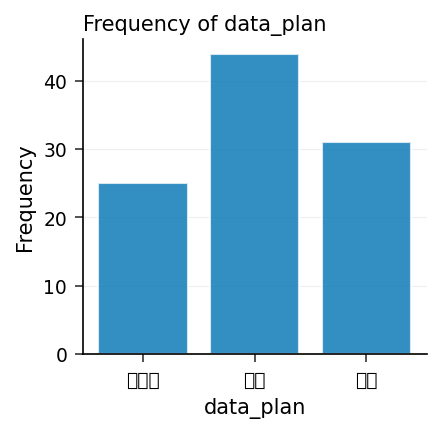

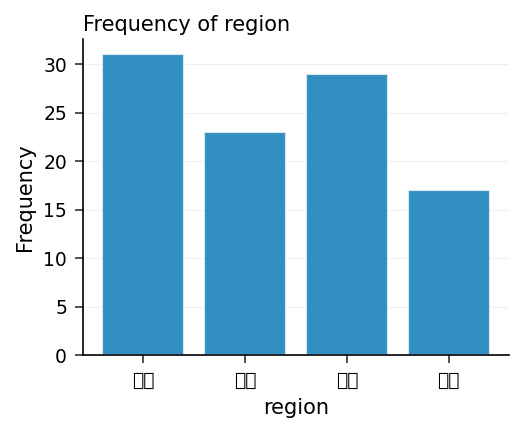

In [2]:
/* 군집화 입력 변수에 대한 요약 통계 */
처리 평균 데이터=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    변수 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    라벨 tenure_months   = "가입 기간(개월)"
          monthly_data_gb = "월간 데이터(GB)"
          voice_minutes   = "음성 통화(분)"
          sms_count       = "SMS 건수"
          intl_minutes    = "국제 통화(분)"
          arpu            = "ARPU(달러)"
          support_calls   = "고객센터 문의 건수";
실행;

/* 범주형 입력 변수 2개의 빈도 */
처리 빈도 데이터=subscribers;
    TABLES data_plan region / nocum;
    라벨 data_plan = "요금제"
          region    = "지역";
실행;


## 3. 특성을 z-점수로 표준화

`PROC FASTCLUS`는 유클리드 거리를 최소화하므로, 수백 분 단위로 측정되는 변수가 한 자릿수 기가바이트 단위로 측정되는 변수를 압도하게 된다. `METHOD=STD`를 지정한 `PROC STDIZE`는 각 구간형 특성을 평균 0, 표준편차 1로 재조정하여 모든 행동이 거리 계산에서 동등한 가중치를 갖도록 한다. 범주형 열과 식별자는 그대로 통과시켜, 이후 원래 스케일로 클러스터를 프로파일링할 수 있게 한다.

In [3]:
/* 구간형 변수를 z-점수로 표준화; id와 범주형 변수는 그대로 통과 */
처리 stdize 데이터=subscribers out=subs_std METHOD=std;
    변수 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
실행;



NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. k-평균 세그먼트 적합

`PROC FASTCLUS`로 세그먼트 3개를 적합한다. `MAXCLUSTERS=3`은 *k*를 설정하고, `MAXITER=20`은 클러스터 중심이 수렴할 때까지 반복하도록 한다. 이 프로시저는 **클러스터 요약**(클러스터별 크기와 클러스터 내 RMS 편차), **변수별 통계**(각 특성이 기여하는 R-제곱), 세 클러스터가 기반을 얼마나 깔끔하게 분리하는지 나타내는 **전체 R-제곱**과 **pseudo-F**, 표준화 스케일의 **클러스터 평균**을 보고한다. `OUT=scored`는 입력 행을 `CLUSTER` 라벨과 각 가입자에서 해당 클러스터 시드까지의 `DISTANCE`와 함께 다시 기록한다.

In [4]:
/* 표준화된 변수로 k-평균 군집화 적합: 3개 세그먼트. */
처리 FASTCLUS 데이터=subs_std maxclusters=3 MAXITER=20 out=scored;
    변수 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    라벨 tenure_months   = "가입 기간(개월)"
          monthly_data_gb = "월간 데이터(GB)"
          voice_minutes   = "음성 통화(분)"
          sms_count       = "SMS 건수"
          intl_minutes    = "국제 통화(분)"
          arpu            = "ARPU(달러)"
          support_calls   = "고객센터 문의 건수";
실행;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. 세그먼트 라벨을 원래 스케일 데이터에 연결

채점 테이블에는 표준화된 특성이 담겨 있지만, 프로파일링을 위해서는 클러스터를 실제 기가바이트, 분, 달러 단위로 설명하고 싶다. `subscriber_id` 기준으로 `CLUSTER` 라벨을 원래의 `subscribers` 테이블에 다시 결합한 뒤, 마케팅팀이 항상 가장 먼저 묻는 질문을 던진다. *각 세그먼트의 규모는 얼마나 되는가?*

                                                   The FREQ Procedure

세그먼트            Frequency    Percent
-------------------------------------
1                      36     36.00
2                      34     34.00
3                      30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


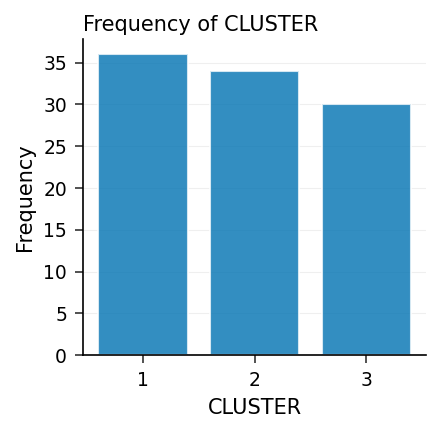

In [5]:
/* 군집 라벨을 원래 스케일의 데이터로 다시 연결 */
처리 정렬 데이터=scored(유지=subscriber_id CLUSTER distance) out=clus_assign;
    기준 subscriber_id;
실행;
처리 정렬 데이터=subscribers out=subs_sorted;
    기준 subscriber_id;
실행;
데이터 profile;
    결합 subs_sorted clus_assign;
    기준 subscriber_id;
실행;

/* 각 세그먼트에 가입자가 몇 명씩 배정되었는가? */
처리 빈도 데이터=profile;
    TABLES CLUSTER / nocum;
    라벨 CLUSTER = "세그먼트";
실행;


## 6. 세그먼트 프로파일링

클러스터 ID는 그 안의 *행동*을 설명하기 전까지는 의미가 없다. `CLUSTER`별로 원래(비표준화) 특성의 평균을 구하면 각 세그먼트 뒤에 있는 페르소나 -- 누가 스트리밍을 하는지, 누가 통화를 많이 하는지, 누가 네트워크를 거의 쓰지 않는지 -- 가 드러나며, 범주형 구성비는 어떤 요금제와 지역이 각 세그먼트에 집중되어 있는지 보여준다.

                                                  The MEANS Procedure

                                Analysis Variable : tenure_months 가입 기간(개월)

        세그먼트                  N Obs           Mean
        ------------------------------------------
        1                        36           28.9
        2                        34           25.8
        3                        30           28.1
        ------------------------------------------

                                Analysis Variable : monthly_data_gb 월간 데이터(GB)

        세그먼트                  N Obs           Mean
        ------------------------------------------
        1                        36            4.0
        2                        34           10.2
        3                        30           44.4
        ------------------------------------------

                                  Analysis Variable : voice_minutes 음성 통화(분)

        세그먼트                  N Obs           Mean
        ---------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


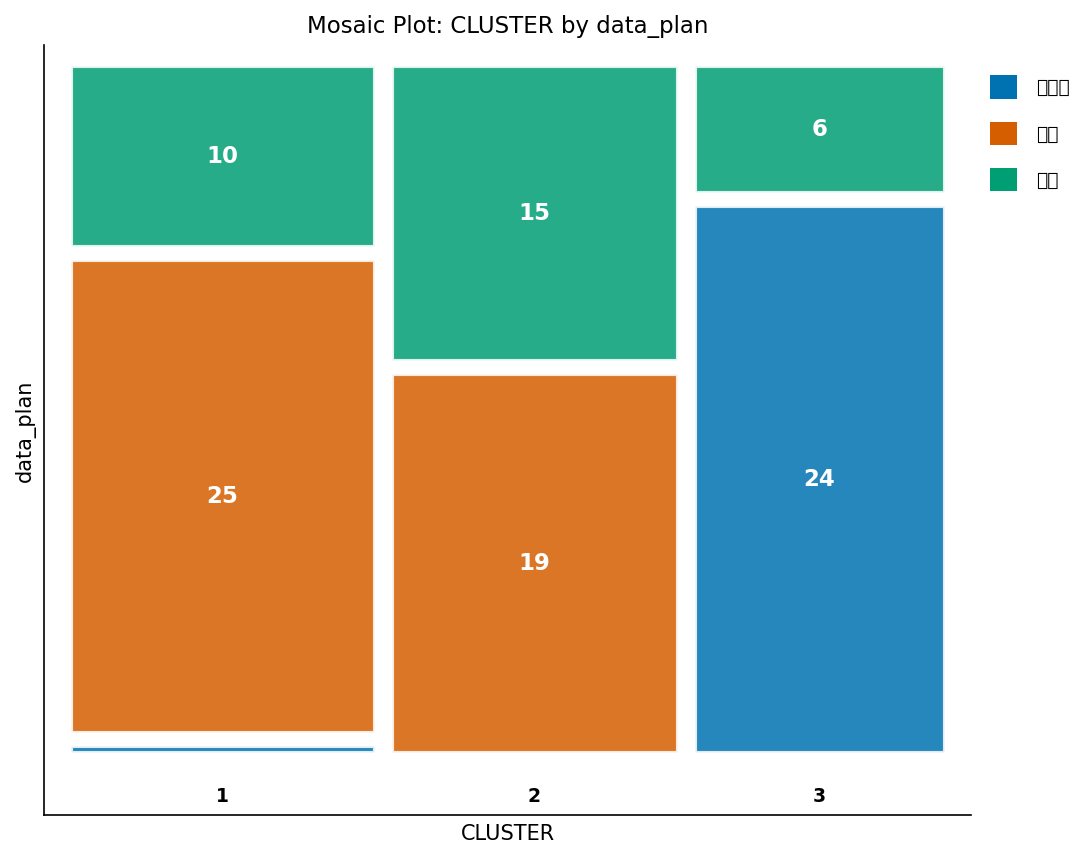

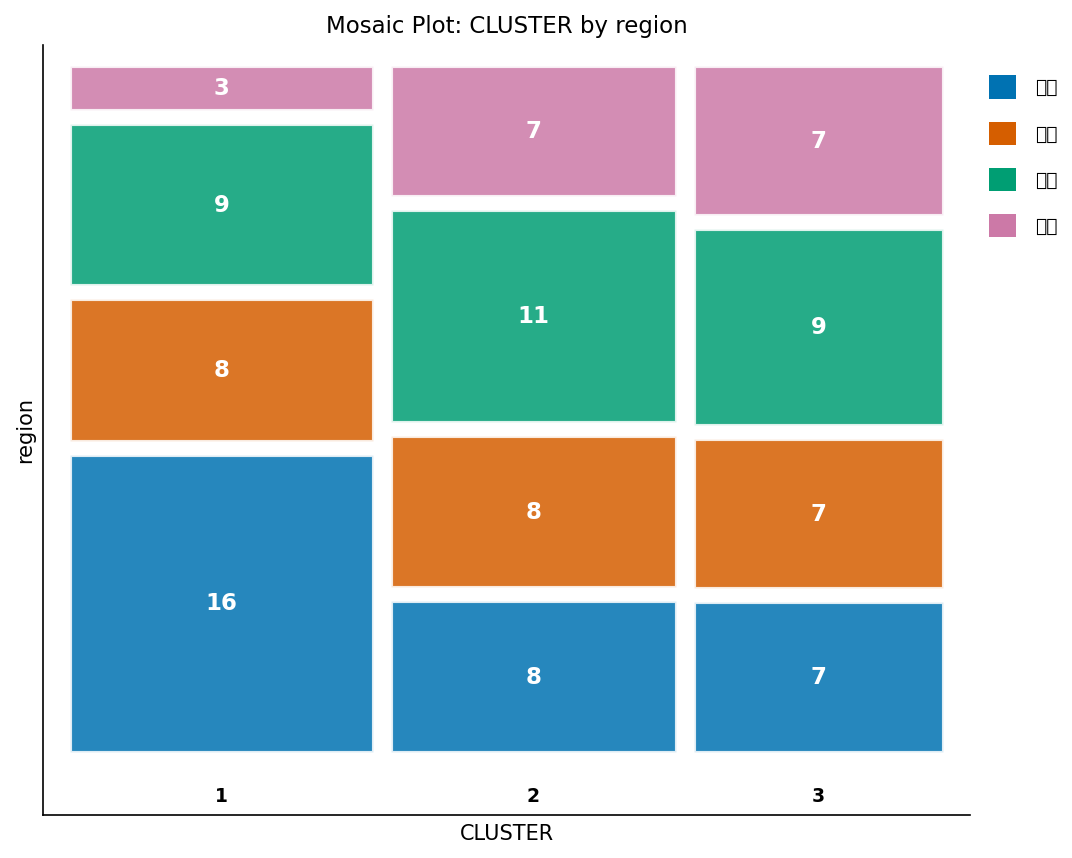

In [6]:
/* 행동 프로파일: 세그먼트별 각 변수의 평균 */
처리 평균 데이터=profile n mean maxdec=1;
    분류 CLUSTER;
    변수 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    라벨 CLUSTER         = "세그먼트"
          tenure_months   = "가입 기간(개월)"
          monthly_data_gb = "월간 데이터(GB)"
          voice_minutes   = "음성 통화(분)"
          sms_count       = "SMS 건수"
          intl_minutes    = "국제 통화(분)"
          arpu            = "ARPU(달러)"
          support_calls   = "고객센터 문의 건수";
실행;

/* 각 세그먼트 내 범주형 구성비 */
처리 빈도 데이터=profile;
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
    라벨 CLUSTER   = "세그먼트"
          data_plan = "요금제"
          region    = "지역";
실행;


## 7. 세그먼트 시각화

그림으로 보면 세그먼트 분석이 훨씬 와닿는다. 데이터 소비량과 음성 사용량을 세그먼트별 색상으로 구분해 그리고, 세그먼트별 ARPU 박스플롯을 추가하여 매출 스토리를 한눈에 보이게 한다.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


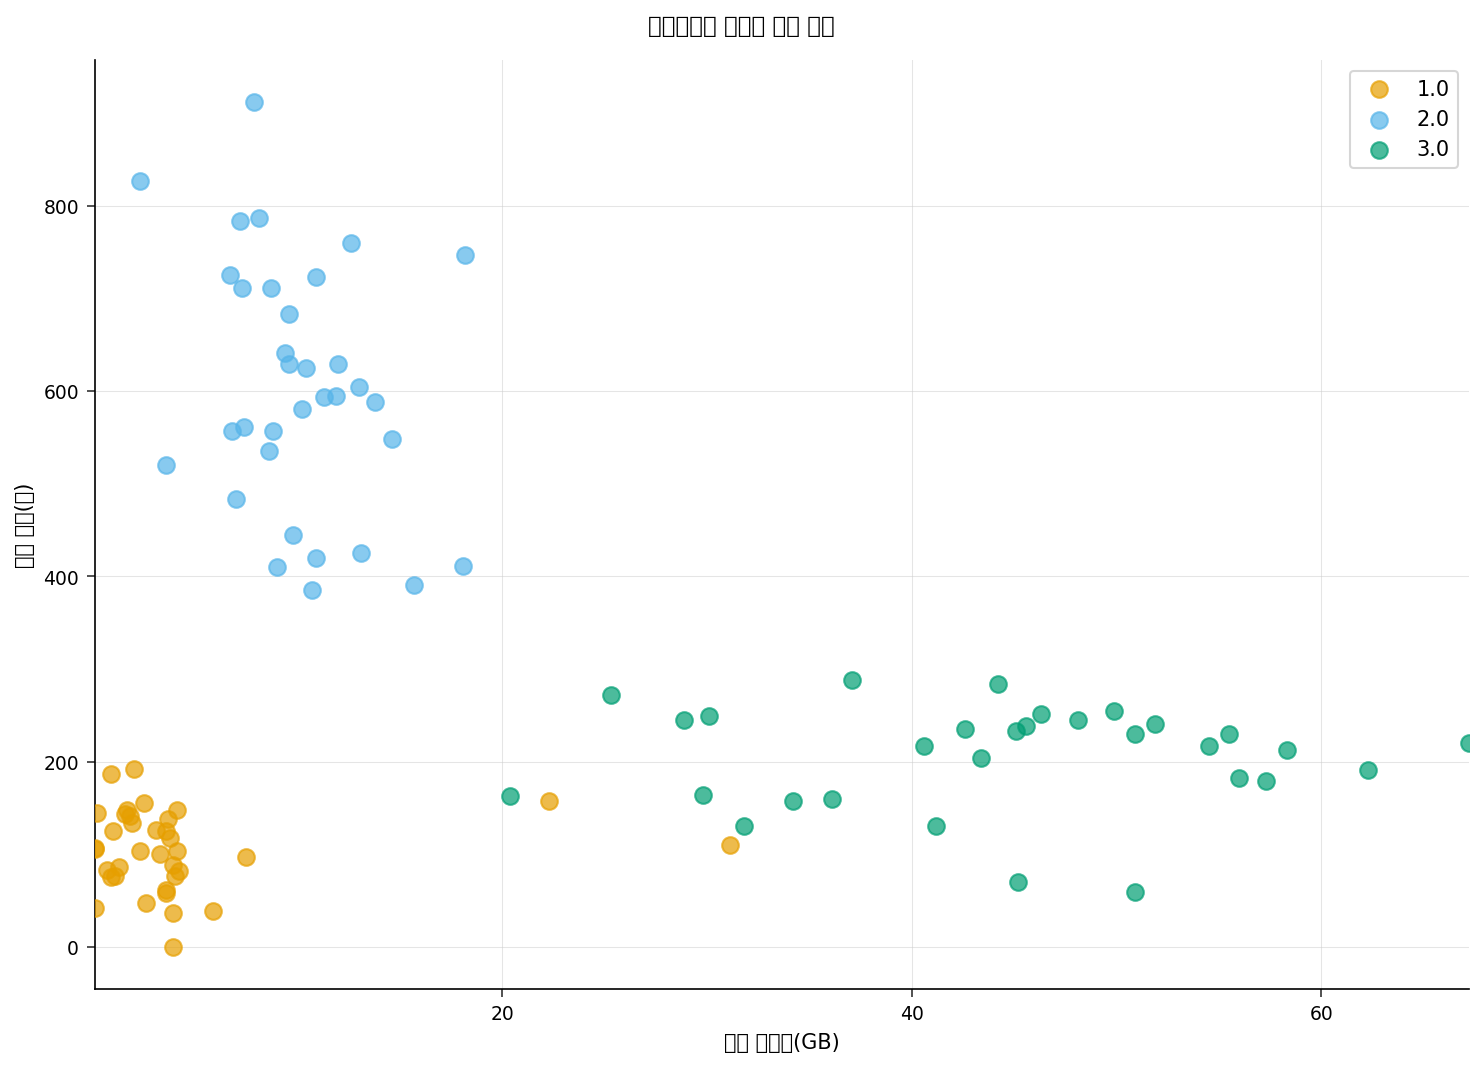

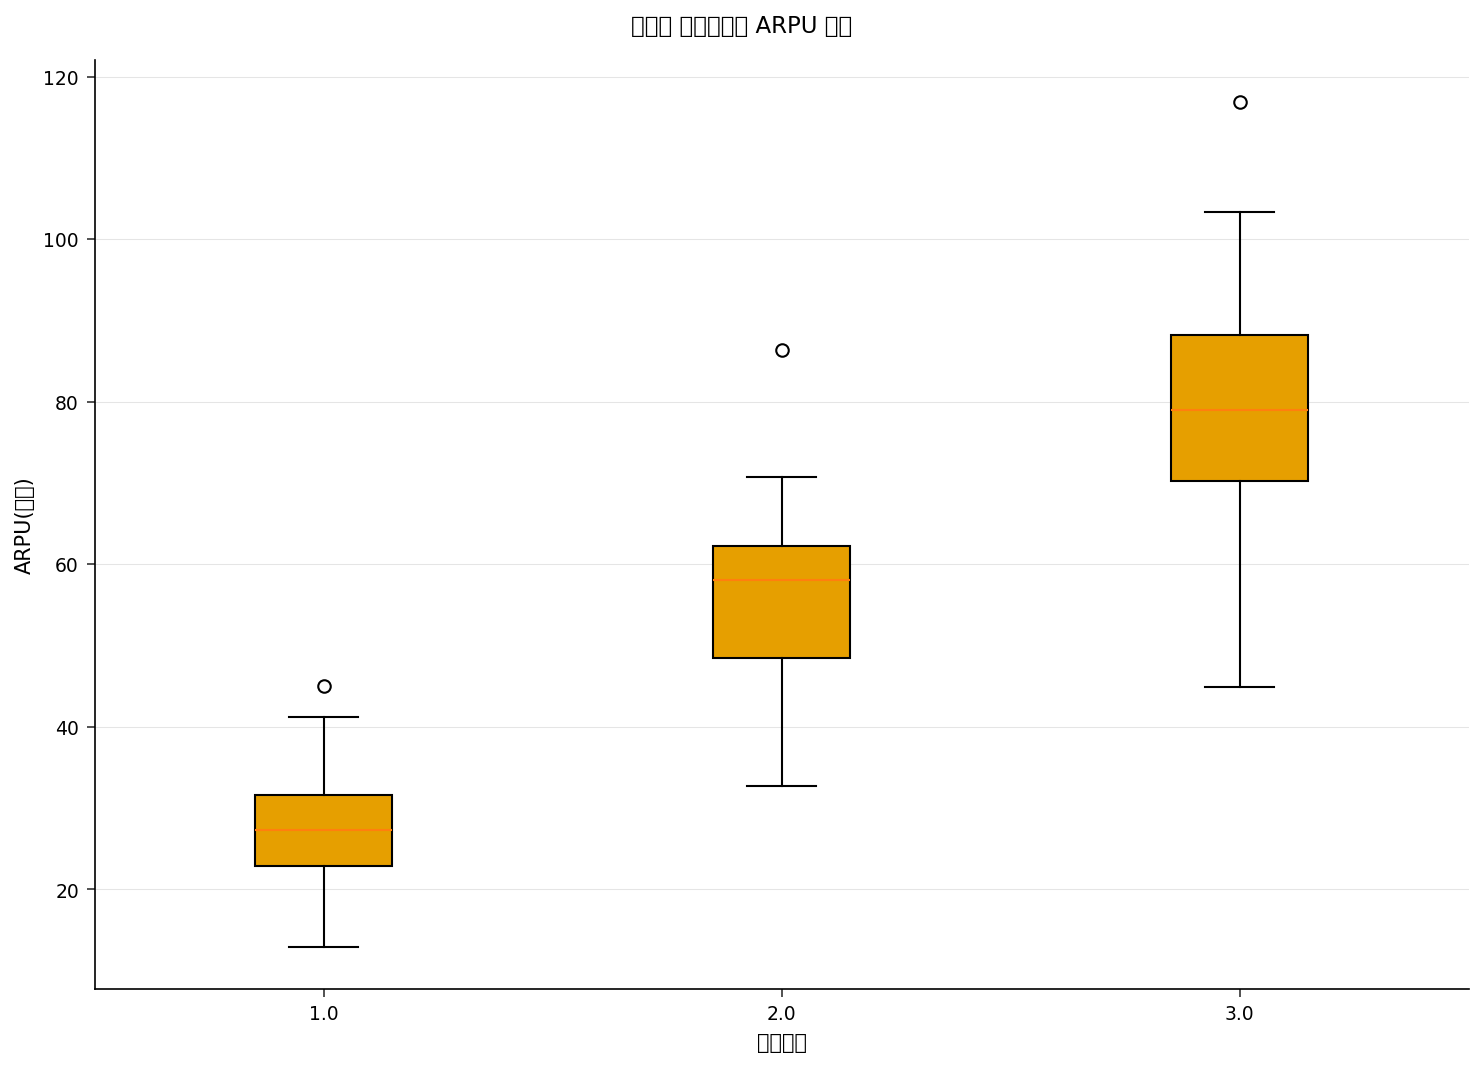

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* 행동 지도: 데이터 사용량 대 음성 사용량, 세그먼트별 색상 구분 */
처리 SGPLOT 데이터=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS 라벨="월간 데이터(GB)" grid;
    YAXIS 라벨="음성 통화(분)"   grid;
    제목 "세그먼트별 가입자 행동 지도";
실행;

/* 세그먼트별 매출(ARPU) 분포 */
처리 SGPLOT 데이터=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS 라벨="세그먼트";
    YAXIS 라벨="ARPU(달러)" grid;
    제목 "가입자 세그먼트별 ARPU 분포";
실행;


## 8. 채점된 세그먼트 내보내기

마지막으로 배정 결과를 후속 CRM 및 캠페인 시스템으로 넘긴다. 식별자, 클러스터 라벨, 핵심 행동 필드를 유지한다.

In [8]:
/* 활성화 단계로 넘길 세그먼트 배정 결과를 저장 */
데이터 subscriber_segments;
    설정 profile;
    유지 subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
실행;

처리 인쇄 데이터=subscriber_segments(obs=10) noobs 라벨;
    라벨 subscriber_id   = "가입자 ID"
          CLUSTER         = "세그먼트"
          tenure_months   = "가입 기간(개월)"
          monthly_data_gb = "월간 데이터(GB)"
          voice_minutes   = "음성 통화(분)"
          arpu            = "ARPU(달러)"
          data_plan       = "요금제"
          region          = "지역";
    제목 "채점된 가입자 세그먼트 샘플";
실행;


                                                    채점된 가입자 세그먼트 샘플                                                     

      가입자 ID          세그먼트              가입 기간(개월)            월간 데이터(GB)            음성 통화(분)      ARPU(달러)        요금제      지역
      100001             1                     30                   2.3                 104            28  선불         남부
      100002             2                      8                  10.2                 581         57.78  선불         서부
      100003             2                      8                  10.7                 385         55.66  후불         북부
      100004             2                     68                   7.4                 561         70.68  선불         북부
      100005             3                     18                  45.6                 239         63.85  무제한        북부
      100006             3                     10                  30.1                 249         88.33  무제한        동부
      100007             1 


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## 결과 해석

`PROC FASTCLUS`는 깔끔하게 잘 분리된 세그먼트 3개를 찾아냈다. 적합도는 양호하다. **전체 R-제곱은 0.575**, **pseudo-F는 65.75**로, 세 클러스터가 표준화된 특성의 전체 변동 중 약 58%를 설명한다는 뜻이다. 이 분리는 우리가 주목하는 행동 신호 -- `voice_minutes`(R-제곱 0.858), `monthly_data_gb`(0.844), `arpu`(0.771) -- 가 거의 전적으로 이끌며, `tenure_months`(0.000)와 `support_calls`(0.193)는 거의 기여하지 않는다. 이는 가입 기간이 아니라 가입자가 *네트워크를 어떻게 사용하는지*가 페르소나를 정의한다는 것을 확인해 준다.

세 세그먼트는 마케팅에 바로 활용 가능한 페르소나로 직접 대응되며, 여기서는 원래(비표준화) 스케일로 프로파일링했다.

| 세그먼트 | n (비중) | 대표 행동 | 요금제 구성 | 페르소나 | 추천 전략 |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | 최고 데이터 사용: **월 44.4GB**, 최고 지출 **ARPU $79.1**, 음성은 보통 (205분) | 24/30 **무제한** | **데이터 다량 스트리머** | 보호 및 업셀: 고속 요금제, 콘텐츠 번들, 기기 업그레이드 |
| **2** | 34 (34%) | 최고 음성 사용 **월 603분**, **SMS 214건**, **국제통화 106분**, 중간 지출 **ARPU $55.9** | 선불 + 후불, **무제한 없음** | **음성 중심 전통 이용자** | 국제전화 부가서비스, 가족/음성 번들, 로열티 리워드 |
| **1** | 36 (36%) | 최저 사용량: **4.0GB**, 음성 104분, 최저 지출 **ARPU $28.0** | 25/36 **선불** | **경량/저사용** | 요금제 최적화, 자동이체 유도, 사용량 확대를 위한 저가 데이터 스타터 |

요금제 구성은 행동 해석을 뒷받침한다. 데이터 다량 세그먼트는 압도적으로 **무제한** 요금제(30명 중 24명)를 쓰고, 음성 중심 세그먼트에는 무제한 가입자가 **전혀 없으며**, 저사용 세그먼트는 대부분 **선불**(36명 중 25명) 요금제를 쓴다. 반면 지역은 세 세그먼트에 고르게 분포되어 있다 -- 지리적 요인은 이곳에서 행동을 좌우하지 않으며, 이는 캠페인 타겟팅에 있어 그 자체로 유용한 발견이다.

**`PROC FASTCLUS`가 이 문제에 적합한 이유.** 전체 거리 행렬을 만드는 대신 데이터를 한 번씩 훑어 분리형 k-평균을 수행하므로, 이 100명의 가입자를 세그먼트화한 동일한 프로그램이 매우 큰 가입자 기반으로도 확장된다. 먼저 `PROC STDIZE`로 표준화하여 기가바이트, 분, 달러 사이의 단위 스케일 편향을 제거함으로써 모든 행동이 유클리드 거리에 동등하게 기여하도록 했고, R-제곱 진단은 실제로 *어떤* 특성이 분리를 이끌었는지 알려주었다. 채점된 결과물 -- 모든 가입자에 붙은 `CLUSTER` 라벨 -- 은 활성화 파이프라인에 곧바로 투입되어, 원시 행동 데이터에서 타겟 오퍼까지의 흐름을 완성한다.

---

<div style="font-size:11px;color:#9e9e9e">이 노트북은 시연 목적으로만 제공됩니다. 데이터는 합성 데이터이며, 이 결과는 비즈니스 조언을 구성하지 않습니다.</div>